# Phase 4 Notebook: Temporal CNN Forecasting

## What was done
- Built a temporal CNN forecaster in PyTorch for next-gameweek points.
- Trained on leakage-safe engineered features with strict chronological handling.
- Added uncertainty-aware predictions and forecast output contracts.

## Why it was done
- Temporal CNN captures momentum and short-run trajectory effects from rolling windows.
- Contract-based outputs make downstream optimisation and agent integration stable.

In [1]:
from pathlib import Path
import pandas as pd

from fpl_ai_agent.features.store import build_player_gameweek_features
from fpl_ai_agent.forecasting.trainer import ForecastTrainerConfig, train_forecaster, predict_with_uncertainty
from fpl_ai_agent.forecasting.inference import build_forecast_contracts

raw = pd.read_csv(Path('../tests/fixtures/raw/fpl_players_sample.csv'))
feat = build_player_gameweek_features(raw, window_short=3, window_long=5, min_history=3)
feature_cols = [
    'minutes_prev', 'goals_prev', 'assists_prev', 'ict_prev', 'bps_prev',
    'price_prev', 'fixture_difficulty', 'home_prev', 'form_points_3',
    'form_points_5', 'minutes_rolling_3', 'ict_rolling_3', 'bps_rolling_3',
    'expected_involvement_proxy', 'injury_risk_proxy', 'value_signal'
]
cfg = ForecastTrainerConfig(
    feature_cols=feature_cols,
    target_col='target_points',
    window_length=3,
    train_seasons={2024},
    valid_seasons=set(),
    test_seasons=set(),
    epochs=5,
    batch_size=8,
    learning_rate=0.001,
    model_version='temporal_cnn_v1_notebook',
)
bundle = train_forecaster(feat, cfg)
windowed, mean_pred, std_pred = predict_with_uncertainty(bundle, feat, target_col='target_points')
contracts = build_forecast_contracts(windowed, mean_pred, std_pred, model_version=bundle.model_version, horizon=1)
len(contracts), bundle.metrics

(1, {'valid_mae': 0.0, 'valid_rmse': 0.0, 'test_mae': 0.0, 'test_rmse': 0.0})

## Data quality checks
- Verify temporal input tensor shape `(samples, window_length, features)`.
- Verify uncertainty is non-negative and availability probability is bounded.
- Verify prediction contract completeness for each sample.

In [2]:
dq = {
    'num_samples': int(windowed.x.shape[0]),
    'window_length': int(windowed.x.shape[1]) if windowed.x.shape[0] else 0,
    'num_features': int(windowed.x.shape[2]) if windowed.x.shape[0] else 0,
    'negative_uncertainty_count': int((std_pred < 0).sum()),
    'availability_prob_out_of_bounds': int(sum((c.availability_probability < 0 or c.availability_probability > 1) for c in contracts)),
}
dq

{'num_samples': 1,
 'window_length': 3,
 'num_features': 16,
 'negative_uncertainty_count': 0,
 'availability_prob_out_of_bounds': 0}

## Findings and anomalies
- Small fixture data can produce unstable metrics and uncertainty estimates.
- Early gameweeks are excluded by minimum history and window constraints.

## How anomalies were handled
- Enforced history threshold and chronological windows.
- Enforced uncertainty floor and bounded availability mapping in contract generation.
- Kept model outputs contract-validated for downstream phases.

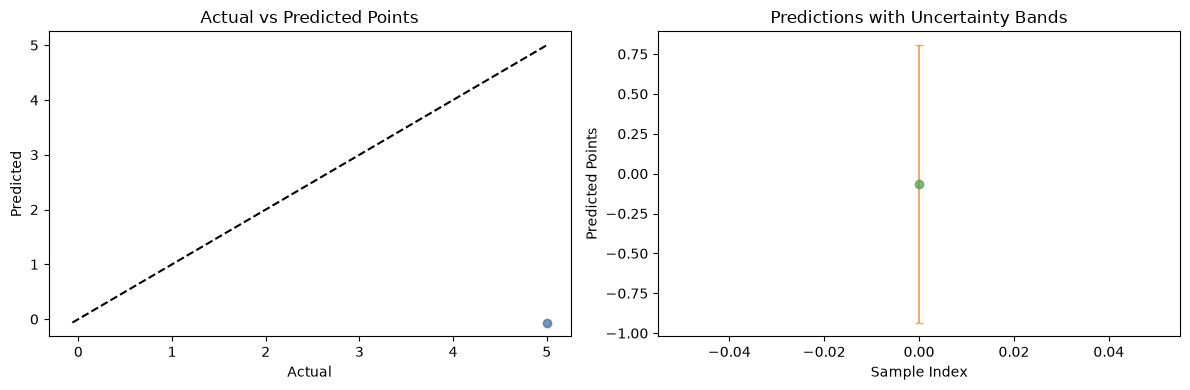

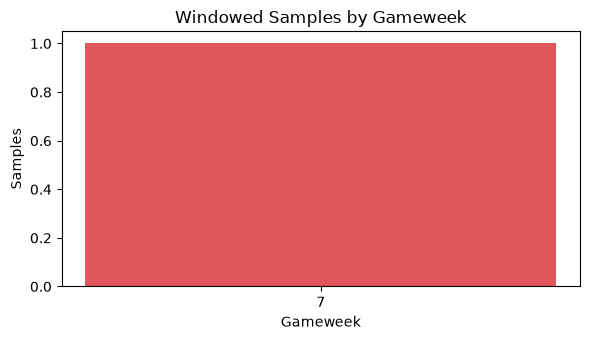

,value
valid_mae,0.0
valid_rmse,0.0
test_mae,0.0
test_rmse,0.0


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pred_df = pd.DataFrame(
    {
        "actual": windowed.y,
        "pred": mean_pred,
        "uncertainty": std_pred,
        "gameweek": windowed.gameweeks,
        "player_id": windowed.player_ids,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(pred_df["actual"], pred_df["pred"], alpha=0.8, color="#4e79a7")
low = float(min(pred_df["actual"].min(), pred_df["pred"].min()))
high = float(max(pred_df["actual"].max(), pred_df["pred"].max()))
axes[0].plot([low, high], [low, high], linestyle="--", color="black")
axes[0].set_title("Actual vs Predicted Points")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

sample_idx = np.arange(len(pred_df))
axes[1].errorbar(
    sample_idx,
    pred_df["pred"],
    yerr=pred_df["uncertainty"],
    fmt="o",
    ecolor="#f28e2b",
    color="#59a14f",
    alpha=0.75,
    capsize=3,
)
axes[1].set_title("Predictions with Uncertainty Bands")
axes[1].set_xlabel("Sample Index")
axes[1].set_ylabel("Predicted Points")

plt.tight_layout()
plt.show()

gw_counts = pred_df["gameweek"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(gw_counts.index.astype(str), gw_counts.values, color="#e15759")
ax.set_title("Windowed Samples by Gameweek")
ax.set_xlabel("Gameweek")
ax.set_ylabel("Samples")
plt.tight_layout()
plt.show()

pd.DataFrame(bundle.metrics, index=["value"]).T